In [92]:
from __future__ import annotations

import operator
from typing import TypedDict, List, Annotated

from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from langchain_core.messages import SystemMessage, HumanMessage

In [ ]:
class Task(BaseModel): #inheriting from pydantic base model
    id: int
    title: str
    brief: str = Field(...,description="What to cover") #no default value

In [94]:
class Plan(BaseModel):
    blog_title: str
    tasks: List[Task]

In [95]:
class State(TypedDict): #Dictionary with this type of keys and val
    topic: str
    plan: Plan
    # reducer: results from workers get concatenated automatically
    sections: Annotated[List[str], operator.add]
    final: str

In [96]:
from dotenv import load_dotenv
from langchain_groq import ChatGroq
import os
load_dotenv()
llm = ChatGroq(
    model="llama-3.1-8b-instant",
    temperature=0.6
)

In [ ]:
import json
def orchestrator(state: State) -> dict:

    plan = llm.with_structured_output(Plan).invoke(
        [
            SystemMessage(
                content=
                "Create a blog plan with 5-7 sections on the following topic."
            ),
            HumanMessage(content=f"Topic: {state['topic']}")
        ]
    )
    print(plan)
    return {"plan": plan}

In [ ]:
import time
def worker(state: State) -> dict :
    sections = []
    for task in state["plan"].tasks:
        output = llm.invoke(
            [
                SystemMessage(content=(
                    "Write one clear markdown section"
                )),
                HumanMessage(content=(
                    f"Blog:{state["plan"].blog_title}, Task:{task.title}, Topic:{state["topic"]}, Brief:{task.brief}. Return only the section content in markdown."
                ))
            ]
        ).content.strip()
        sections.append(output)
        time.sleep(12)

    return {"sections": [output]}

In [100]:
from pathlib import Path
def reducer(state: State) -> dict :
    title = state["plan"].blog_title
    content = "\n\n".join(state["sections"]).strip()

    final_md = f"#{title}\n\n{content}\n"
    filename = title.lower().replace(" ", "_") + ".md"
    output_path = Path(filename)
    output_path.write_text(final_md, encoding="utf-8")

    return {"final": final_md}


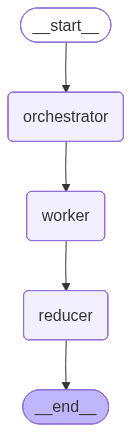

In [101]:
g = StateGraph(State)
g.add_node("orchestrator", orchestrator)
g.add_node("worker", worker)
g.add_node("reducer", reducer)
g.add_edge(START, "orchestrator")
g.add_edge("orchestrator", "worker")
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

app = g.compile()

app

In [102]:
out = app.invoke({'topic': "Write a blog on Stock market"})


blog_title='Understanding the Stock Market' tasks=[Task(id=1, title='What is the Stock Market?', brief='Introduction to the stock market'), Task(id=2, title='Types of Stocks and Shares', brief='Types of stocks and shares'), Task(id=3, title='How to Invest in the Stock Market', brief='How to invest in the stock market'), Task(id=4, title='Risks and Rewards of Investing in the Stock Market', brief='Risks and rewards of investing in the stock market'), Task(id=5, title='Tips and Strategies for Success in the Stock Market', brief='Tips and strategies for success in the stock market'), Task(id=6, title='Common Stock Market Terms and Jargon', brief='Common stock market terms and jargon'), Task(id=7, title='Conclusion and Final Thoughts', brief='Conclusion and final thoughts')]


In [103]:
print(out['plan'])

blog_title='Understanding the Stock Market' tasks=[Task(id=1, title='What is the Stock Market?', brief='Introduction to the stock market'), Task(id=2, title='Types of Stocks and Shares', brief='Types of stocks and shares'), Task(id=3, title='How to Invest in the Stock Market', brief='How to invest in the stock market'), Task(id=4, title='Risks and Rewards of Investing in the Stock Market', brief='Risks and rewards of investing in the stock market'), Task(id=5, title='Tips and Strategies for Success in the Stock Market', brief='Tips and strategies for success in the stock market'), Task(id=6, title='Common Stock Market Terms and Jargon', brief='Common stock market terms and jargon'), Task(id=7, title='Conclusion and Final Thoughts', brief='Conclusion and final thoughts')]
